In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np

import string
from re import sub

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from keras.models import Sequential
from keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

import warnings
warnings.filterwarnings('ignore')

from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.utils import to_categorical

from tensorflow.keras.layers import Input, Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout, Concatenate, BatchNormalization
from tensorflow.keras.regularizers import l2
import time

In [ ]:
train = pd.read_csv('/content/drive/My Drive/HTC_CNN_dataset/WOS/wos_train_final.csv')
test = pd.read_csv('/content/drive/My Drive/HTC_CNN_dataset/WOS/wos_test_final.csv')

In [ ]:
data = train


texts = data['text'].values
labels_l1 = data['l1'].values
labels_l2 = data['l2'].values


label_encoder_l1 = LabelEncoder()
label_encoder_l2 = LabelEncoder()

encoded_l1 = label_encoder_l1.fit_transform(labels_l1)
encoded_l2 = label_encoder_l2.fit_transform(labels_l2)


tokenizer = Tokenizer(num_words=10000)
tokenizer.fit_on_texts(texts)
sequences = tokenizer.texts_to_sequences(texts)
X_padded = pad_sequences(sequences, maxlen=1000)


y_l1 = to_categorical(encoded_l1)
y_l2 = to_categorical(encoded_l2)

In [ ]:
data_test = test


texts_test = data_test['text'].values
labels_l1_test = data_test['l1'].values
labels_l2_test = data_test['l2'].values

encoded_l1_test = label_encoder_l1.transform(labels_l1_test)
encoded_l2_test = label_encoder_l2.transform(labels_l2_test)

sequences_test = tokenizer.texts_to_sequences(texts_test)
X_padded_test = pad_sequences(sequences_test, maxlen=1000)

y_l1_test = to_categorical(encoded_l1_test)
y_l2_test = to_categorical(encoded_l2_test)

In [ ]:
input_text = Input(shape=(1000,))

embedding_text = Embedding(input_dim=10000, output_dim=128, input_length=1000)(input_text)

conv_text = Conv1D(128, 3, activation='relu')(embedding_text)

global_pool_text = GlobalMaxPooling1D()(conv_text)

dense_text_l1 = Dense(128, activation='relu')(global_pool_text)

output_l1 = Dense(len(label_encoder_l1.classes_), activation='softmax')(dense_text_l1)

model_l1 = Model(inputs=input_text, outputs=output_l1)
model_l1.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

early_stopping = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)
begin_l1_time = time.time()
history_l1 = model_l1.fit(X_padded, y_l1, epochs=10, batch_size=128, validation_split=0.2, callbacks=[early_stopping])
end_l1_time = time.time()
l1_time = round(end_l1_time - begin_l1_time)
print(f'Level 1 model training time: {l1_time:.2f} seconds')

Epoch 1/10
196/196 [==============================] - 247s 1s/step - loss: 1.0751 - accuracy: 0.6029 - val_loss: 0.4575 - val_accuracy: 0.8433
Epoch 2/10
196/196 [==============================] - 259s 1s/step - loss: 0.2897 - accuracy: 0.8997 - val_loss: 0.3143 - val_accuracy: 0.8964
Epoch 3/10
196/196 [==============================] - 251s 1s/step - loss: 0.1444 - accuracy: 0.9543 - val_loss: 0.3117 - val_accuracy: 0.8999
Epoch 4/10
196/196 [==============================] - 258s 1s/step - loss: 0.0580 - accuracy: 0.9865 - val_loss: 0.3242 - val_accuracy: 0.8981
Epoch 5/10
196/196 [==============================] - 251s 1s/step - loss: 0.0167 - accuracy: 0.9982 - val_loss: 0.3559 - val_accuracy: 0.8976
l1 模型训练时间: 1266.00 秒


In [ ]:
pred_l1 = model_l1.predict(X_padded)
pred_labels_l1 = label_encoder_l1.inverse_transform(np.argmax(pred_l1, axis=1))
accuracy_l1 = np.mean(pred_labels_l1 == labels_l1)
print(f"Training accuracy for l1: {accuracy_l1:.4f}")

pred_l1_test = model_l1.predict(X_padded_test)
pred_labels_l1_test = label_encoder_l1.inverse_transform(np.argmax(pred_l1_test, axis=1))
accuracy_l1_test = np.mean(pred_labels_l1_test == labels_l1_test)

print(f"Testing accuracy for l1: {accuracy_l1_test:.4f}")

979/979 [==============================] - 82s 83ms/step
Training accuracy for l1: 0.9705
490/490 [==============================] - 39s 79ms/step
Testing accuracy for l1: 0.8948


In [ ]:
input_text_l2 = Input(shape=(1000,))

embedding_text_l2 = Embedding(input_dim=10000, output_dim=128, input_length=1000)(input_text_l2)

conv_text_l2 = Conv1D(128, 3, activation='relu')(embedding_text_l2)


global_pool_text_l2 = GlobalMaxPooling1D()(conv_text_l2)

dense_text_l2 = Dense(128, activation='relu')(global_pool_text_l2)
dropout_text_l2 = Dropout(0.5)(dense_text_l2)

pretrained_l1_features = Model(inputs=input_text, outputs=dense_text_l1)

l1_features = pretrained_l1_features(input_text_l2)

concatenated_l2 = Concatenate()([dropout_text_l2, l1_features])

dense_l2_adjusted = Dense(len(label_encoder_l2.classes_), activation='relu')(concatenated_l2)
dropout_l2_adjusted = Dropout(0.5)(dense_l2_adjusted)

output_l2_adjusted = Dense(len(label_encoder_l2.classes_), activation='softmax')(dropout_l2_adjusted)

model_l2_adjusted = Model(inputs=input_text_l2, outputs=output_l2_adjusted)
model_l2_adjusted.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

early_stopping = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)
begin_l2_time = time.time()
history_l2_adjusted = model_l2_adjusted.fit(X_padded, y_l2, epochs=10, batch_size=128, validation_split=0.2, callbacks=[early_stopping])
end_l2_time = time.time()
l2_time = round(end_l2_time - begin_l2_time)
print(f'Level 2 model training time: {l2_time:.2f} seconds')

Epoch 1/10
196/196 [==============================] - 505s 3s/step - loss: 3.6635 - accuracy: 0.1358 - val_loss: 2.3598 - val_accuracy: 0.4797
Epoch 2/10
196/196 [==============================] - 494s 3s/step - loss: 2.0142 - accuracy: 0.4822 - val_loss: 1.3952 - val_accuracy: 0.7017
Epoch 3/10
196/196 [==============================] - 496s 3s/step - loss: 1.2554 - accuracy: 0.6839 - val_loss: 1.1678 - val_accuracy: 0.7448
Epoch 4/10
196/196 [==============================] - 491s 3s/step - loss: 0.9038 - accuracy: 0.7700 - val_loss: 1.1202 - val_accuracy: 0.7555
Epoch 5/10
196/196 [==============================] - 491s 3s/step - loss: 0.6624 - accuracy: 0.8255 - val_loss: 1.1447 - val_accuracy: 0.7640
Epoch 6/10
196/196 [==============================] - 497s 3s/step - loss: 0.4937 - accuracy: 0.8671 - val_loss: 1.2354 - val_accuracy: 0.7617
l2 模型训练时间: 2973.00 秒


In [ ]:
pred_l2 = model_l2_adjusted.predict(X_padded)
pred_labels_l2 = label_encoder_l2.inverse_transform(np.argmax(pred_l2, axis=1))
accuracy_l2 = np.mean(pred_labels_l2 == labels_l2)
print(f"Training accuracy for l2: {accuracy_l2:.4f}")


pred_l2_test = model_l2_adjusted.predict(X_padded_test)
pred_labels_l2_test = label_encoder_l2.inverse_transform(np.argmax(pred_l2_test, axis=1))
accuracy_l2_test = np.mean(pred_labels_l2_test == labels_l2_test)

print(f"Testing accuracy for l2: {accuracy_l2_test:.4f}")

979/979 [==============================] - 143s 146ms/step
Training accuracy for l2: 0.8803
490/490 [==============================] - 73s 149ms/step
Testing accuracy for l2: 0.7546


In [ ]:
pred_labels_l1_test = label_encoder_l1.inverse_transform(np.argmax(pred_l1_test, axis=1))
pred_labels_l2_test = label_encoder_l2.inverse_transform(np.argmax(pred_l2_test, axis=1))

accuracy_l1 = np.mean(pred_labels_l1_test == labels_l1_test)
accuracy_l2 = np.mean(pred_labels_l2_test == labels_l2_test)

print(f"Accuracy for l1: {accuracy_l1:.4f}")
print(f"Accuracy for l2: {accuracy_l2:.4f}")


correct_l1 = pred_labels_l1_test == labels_l1_test
accuracy_l1 = np.mean(correct_l1)
print(f"Consistency Accuracy for l1: {accuracy_l1:.4f}")

correct_l1_indices = np.where(correct_l1)[0]
pred_labels_l2_filtered = pred_labels_l2_test[correct_l1_indices]
labels_l2_filtered = labels_l2_test[correct_l1_indices]

correct_l2 = pred_labels_l2_filtered == labels_l2_filtered
accuracy_l2 = np.sum(correct_l2) / len(labels_l2_test)
print(f"Consistency Accuracy for l2: {accuracy_l2:.4f}")

Accuracy for l1: 0.8948
Accuracy for l2: 0.7546
Consistency Accuracy for l1: 0.8948
Consistency Accuracy for l2: 0.7340


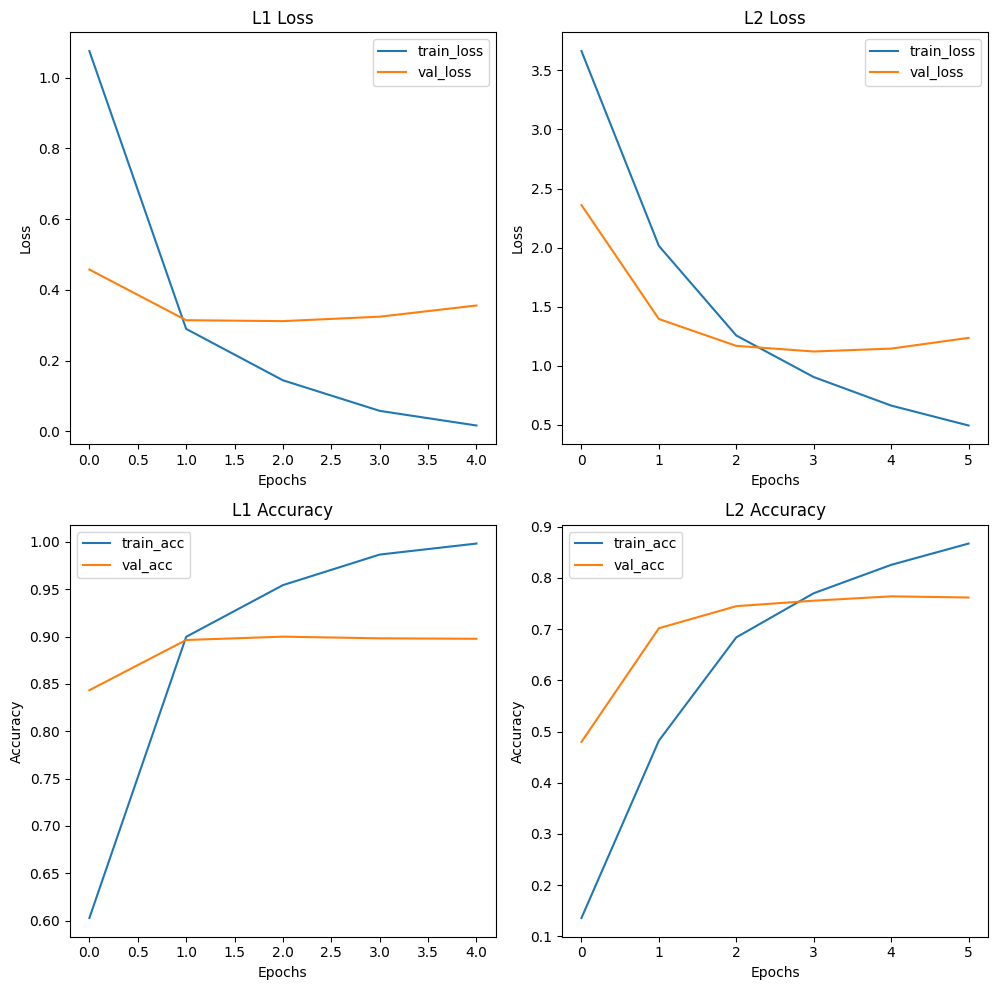

In [ ]:
def plot_history(histories, titles):
    plt.figure(figsize=(15, 10))
    for i, history in enumerate(histories):
        plt.subplot(2, 3, i + 1)
        plt.plot(history.history['loss'], label='train_loss')
        plt.plot(history.history['val_loss'], label='val_loss')
        plt.title(f'{titles[i]} Loss')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.legend()

        plt.subplot(2, 3, i + 4)
        plt.plot(history.history['accuracy'], label='train_acc')
        plt.plot(history.history['val_accuracy'], label='val_acc')
        plt.title(f'{titles[i]} Accuracy')
        plt.xlabel('Epochs')
        plt.ylabel('Accuracy')
        plt.legend()

    plt.tight_layout()
    plt.show()

plot_history([history_l1, history_l2_adjusted], ['L1', 'L2'])